# Process 1 – Sterilization Simulation Explorer

Use this notebook to inspect and correct the simulation output.
Re-run `generate_process_1.py` after tuning parameters in that file, then re-run this notebook.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

DATA_DIR = Path('..') / 'data' / 'gold' / 'experiment_1' / 'process_1' / 'datasets'

df_event_log      = pd.read_parquet(DATA_DIR / 'df_event_log.parquet')
df_expanded       = pd.read_parquet(DATA_DIR / 'df_expanded.parquet')
df_production_plan = pd.read_parquet(DATA_DIR / 'df_production_plan.parquet')

print('Event log:       ', df_event_log.shape)
print('Expanded:        ', df_expanded.shape)
print('Production plan: ', df_production_plan.shape)

Event log:        (7000, 9)
Expanded:         (35065, 18)
Production plan:  (500, 5)


## 1. Event log overview

In [2]:
print('Columns:', df_event_log.dtypes.to_dict())
df_event_log.head(14)

Columns: {'case_id': dtype('O'), 'activity': dtype('O'), 'timestamp_start': dtype('<M8[ns]'), 'timestamp_end': dtype('<M8[ns]'), 'higher_level_activity': dtype('O'), 'station': dtype('O'), 'object_type': dtype('O'), 'object': dtype('O'), 'object_attributes': dtype('O')}


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,station,object_type,object,object_attributes
0,batch_001,water_supply_prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
1,batch_001,water_supply_working,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
2,batch_001,destillation_heat,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,sterilization_process,Destillation,sterilization_line,destillation,"{'recipe': 'standard', 'volume_L': 463.3}"
3,batch_001,bottling_prepare,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
4,batch_001,bottling_working,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
5,batch_001,bottling_cool,2024-01-15 00:02:33.664783,2024-01-15 00:02:39.224708,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
6,batch_001,autoclaving_1_prepare,2024-01-15 00:02:40.224708,2024-01-15 00:04:40.184385,sterilization_process,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
7,batch_001,autoclaving_1_heat,2024-01-15 00:04:41.184385,2024-01-15 00:22:22.758636,sterilization_process,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
8,batch_002,water_supply_prepare,2024-01-15 00:15:00.000000,2024-01-15 00:15:02.859484,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"
9,batch_002,water_supply_working,2024-01-15 00:15:03.859484,2024-01-15 00:15:38.156163,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"


In [3]:
# Activity counts per station
(
    df_event_log
    .groupby(['station', 'activity'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['station', 'activity'])
)

,station,activity,count
0,Autoclaving,autoclaving_1_cool,169
1,Autoclaving,autoclaving_1_heat,169
2,Autoclaving,autoclaving_1_hold,169
3,Autoclaving,autoclaving_1_prepare,169
4,Autoclaving,autoclaving_2_cool,167
5,Autoclaving,autoclaving_2_heat,167
6,Autoclaving,autoclaving_2_hold,167
7,Autoclaving,autoclaving_2_prepare,167
8,Autoclaving,autoclaving_3_cool,164
9,Autoclaving,autoclaving_3_heat,164


## 2. pm4py Directly-Follows Graph (DFG)

### 2a. Activity-level DFG

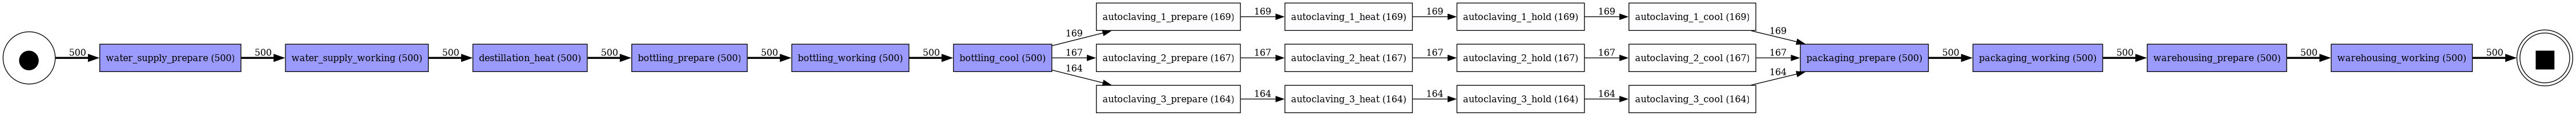

In [4]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Convert to pm4py event log format
el_pm4py = df_event_log.rename(columns={
    "case_id": "case:concept:name",
    "activity": "concept:name",
    "timestamp_start": "time:timestamp",
})

el_pm4py["time:timestamp"] = pd.to_datetime(el_pm4py["time:timestamp"])

log = pm4py.convert_to_event_log(el_pm4py)

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

gviz = dfg_vis.apply(
    dfg,
    log=log,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz, f.name)
    display(Image(filename=f.name))

### 2b. Station-level DFG  (higher_level_activity)

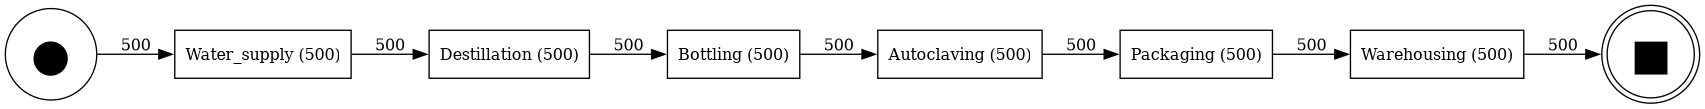

In [5]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Use first event per (case_id, station) as the station-level trace
station_log = (
    df_event_log
    .sort_values("timestamp_start")
    .groupby(["case_id", "station"], sort=False)
    .first()
    .reset_index()
    .rename(columns={
        "case_id": "case:concept:name",
        "station": "concept:name",
        "timestamp_start": "time:timestamp",
    })
)

station_log["time:timestamp"] = pd.to_datetime(station_log["time:timestamp"])

log_station = pm4py.convert_to_event_log(station_log)

dfg_s, sa_s, ea_s = pm4py.discover_dfg(log_station)

gviz_s = dfg_vis.apply(
    dfg_s,
    log=log_station,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": sa_s,
        "end_activities": ea_s
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz_s, f.name)
    display(Image(filename=f.name))

## 3. Process model – Inductive Miner (Petri net)

Petri nets discovered with the **Inductive Miner** give you a formal model of the control flow. A green square = source place (start), a red square = sink place (end), rounded boxes = transitions (activities).

### 3a. Activity-level Petri net

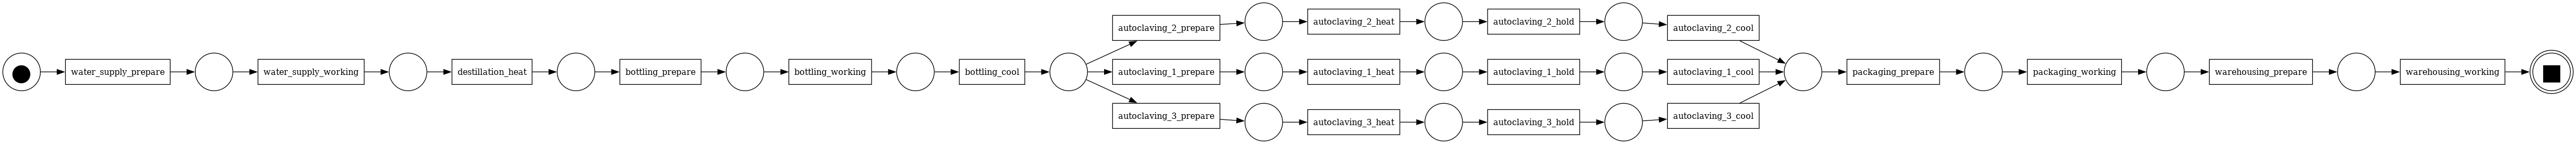

In [6]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the activity-level log
net_a, im_a, fm_a = pm4py.discover_petri_net_inductive(log)

gviz_pn_a = pn_vis.apply(
    net_a,
    im_a,
    fm_a,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_a, f.name)
    display(Image(filename=f.name))

### 3b. Station-level Petri net

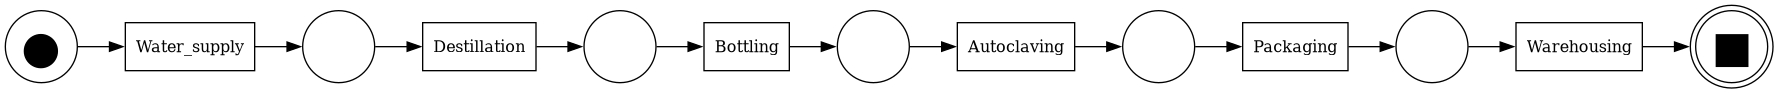

In [7]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the station-level log
net_s, im_s, fm_s = pm4py.discover_petri_net_inductive(log_station)

gviz_pn_s = pn_vis.apply(
    net_s,
    im_s,
    fm_s,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log_station}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_s, f.name)
    display(Image(filename=f.name))

## 3. Duration distributions per station / activity

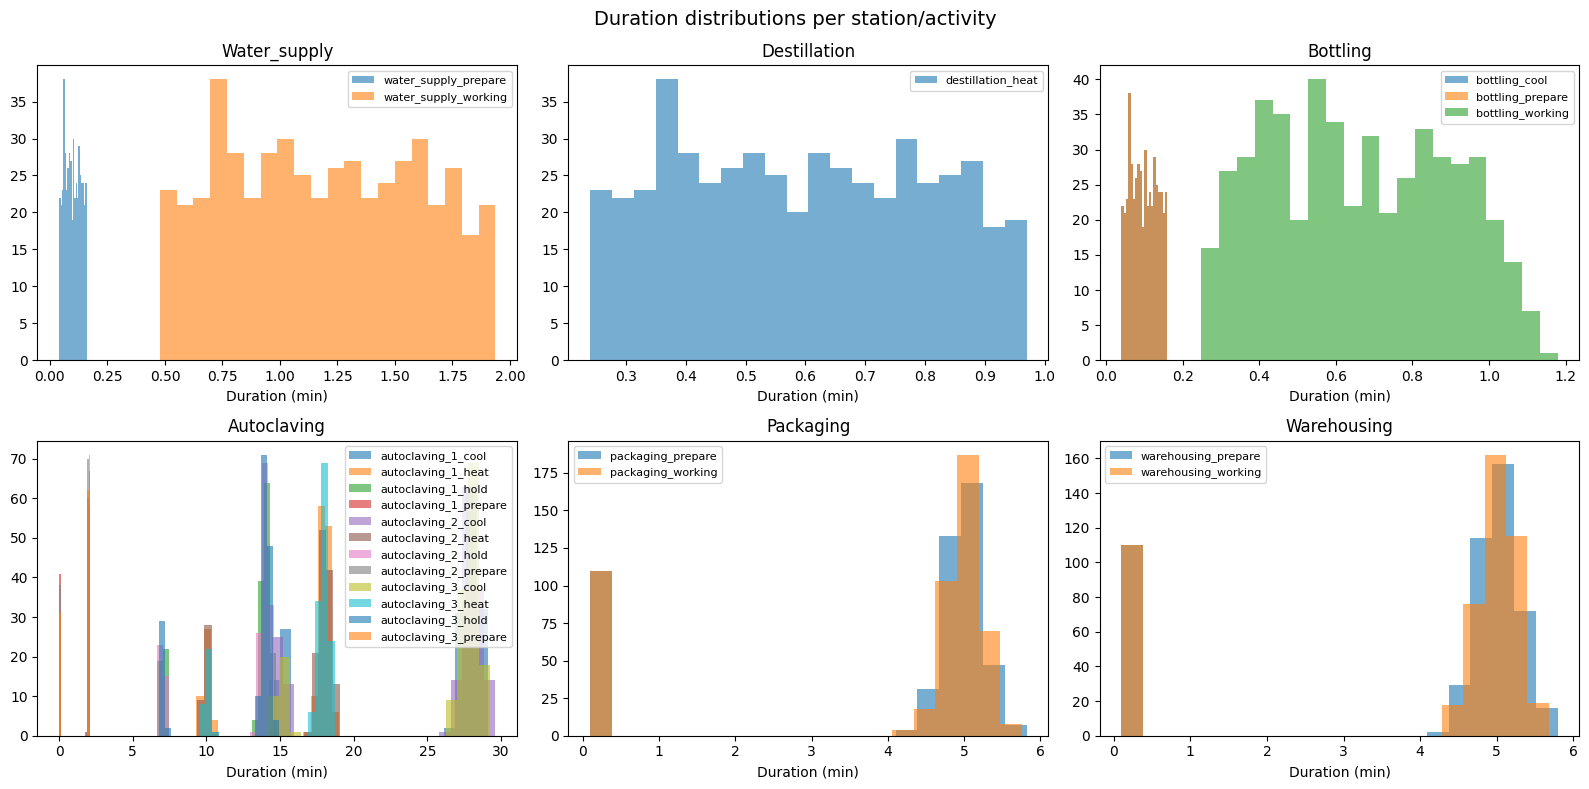

In [8]:
df_event_log['duration_min'] = (
    (df_event_log['timestamp_end'] - df_event_log['timestamp_start'])
    .dt.total_seconds() / 60
)

stations = df_event_log['station'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, station in zip(axes, stations):
    sub = df_event_log[df_event_log['station'] == station]
    for act, grp in sub.groupby('activity'):
        ax.hist(grp['duration_min'], bins=20, alpha=0.6, label=act)
    ax.set_title(station)
    ax.set_xlabel('Duration (min)')
    ax.legend(fontsize=8)

plt.suptitle('Duration distributions per station/activity', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Gantt chart – batch timeline (first 20 batches)

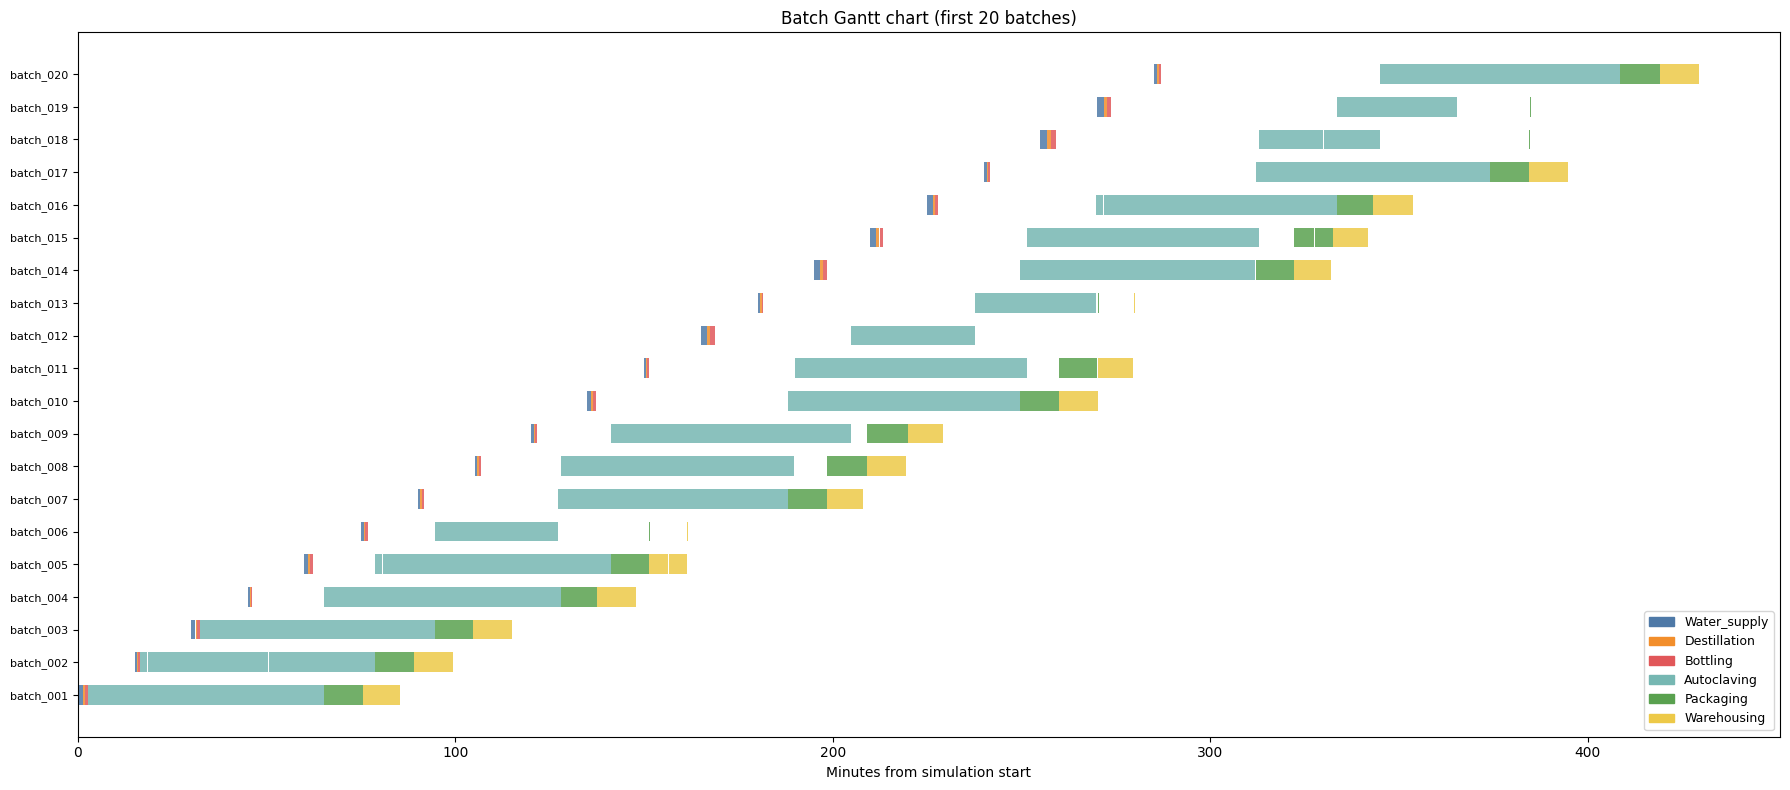

In [9]:
N_GANTT = 20
batches = df_event_log['case_id'].unique()[:N_GANTT]

STATION_COLORS = {
    'Water_supply':  '#4e79a7',
    'Destillation':  '#f28e2b',
    'Bottling':      '#e15759',
    'Autoclaving':   '#76b7b2',
    'Packaging':     '#59a14f',
    'Warehousing':   '#edc948',
}

fig, ax = plt.subplots(figsize=(18, 8))
t0 = df_event_log['timestamp_start'].min()

for yi, bid in enumerate(batches):
    sub = df_event_log[df_event_log['case_id'] == bid]
    for _, row in sub.iterrows():
        start = (row['timestamp_start'] - t0).total_seconds() / 60
        dur   = (row['timestamp_end']   - row['timestamp_start']).total_seconds() / 60
        color = STATION_COLORS.get(row['station'], 'grey')
        ax.barh(yi, dur, left=start, height=0.6, color=color, alpha=0.85)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(batches, fontsize=8)
ax.set_xlabel('Minutes from simulation start')
ax.set_title('Batch Gantt chart (first 20 batches)')
patches = [mpatches.Patch(color=c, label=s) for s, c in STATION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Energy curves – sample batches

Each subplot shows one energy sensor over time, colored by activity.

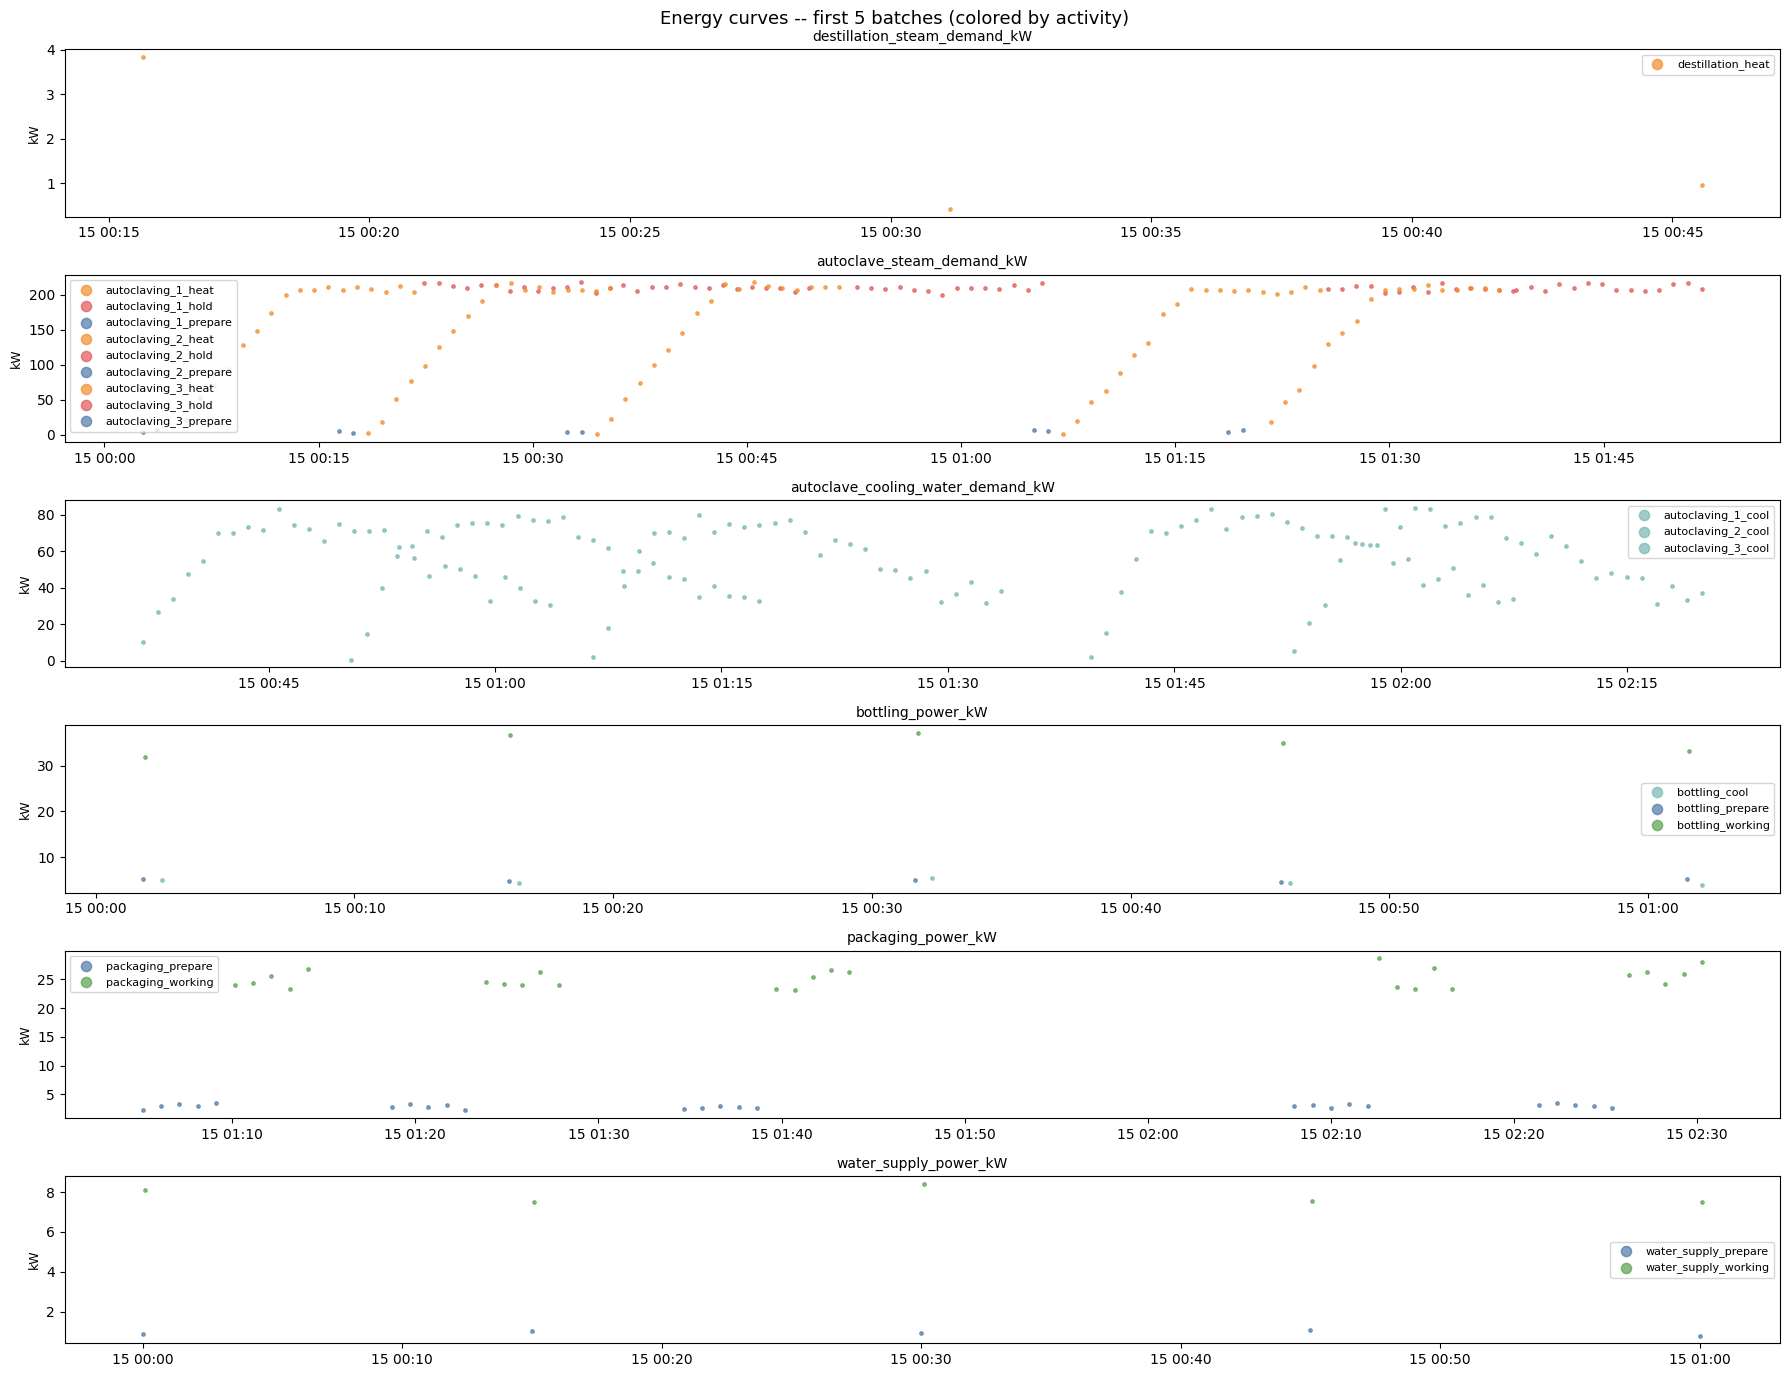

In [10]:
ENERGY_SENSORS = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]

ACTIVITY_COLORS = {
    'prepare': '#4e79a7',
    'heat':    '#f28e2b',
    'hold':    '#e15759',
    'cool':    '#76b7b2',
    'working': '#59a14f',
}

# Show first 5 batches for clarity
SAMPLE_BATCHES = df_event_log['case_id'].unique()[:5]
sub_exp = df_expanded[df_expanded['case_id_log'].isin(SAMPLE_BATCHES)].copy()

fig, axes = plt.subplots(len(ENERGY_SENSORS), 1, figsize=(18, 14), sharex=False)

for ax, sensor in zip(axes, ENERGY_SENSORS):
    active = sub_exp[sub_exp[sensor] > 0].copy()
    if active.empty:
        ax.set_title(sensor + ' -- no data')
        continue
    for act, grp in active.groupby('activity_log'):
        # activity_log is now 'resource_actname' (e.g. 'autoclaving_1_heat')
        short = act.split('_')[-1]
        color = ACTIVITY_COLORS.get(short, 'grey')
        ax.scatter(grp['datetime_energy'], grp[sensor],
                   s=6, color=color, alpha=0.7, label=act)
    ax.set_ylabel('kW', fontsize=9)
    ax.set_title(sensor.replace('_energy', ''), fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Energy curves -- first 5 batches (colored by activity)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Weather vs. energy – verifying physical relationships

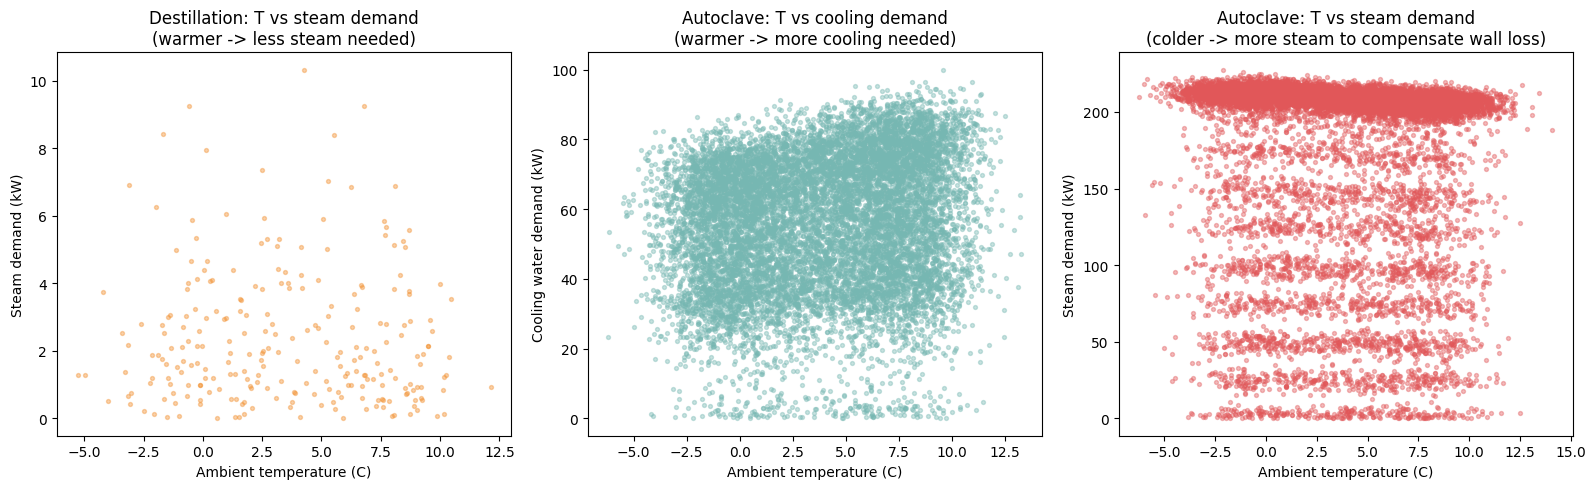

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Temperature vs. distillation steam demand
dest = df_expanded[df_expanded['destillation_steam_demand_kW_energy'] > 0]
axes[0].scatter(dest['ef_temperature_2m_energy'],
                dest['destillation_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#f28e2b')
axes[0].set_xlabel('Ambient temperature (C)')
axes[0].set_ylabel('Steam demand (kW)')
axes[0].set_title('Destillation: T vs steam demand\n(warmer -> less steam needed)')

# 6b. Temperature vs. autoclave cooling water demand (cool phase only)
cool = df_expanded[
    (df_expanded['autoclave_cooling_water_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].str.endswith('_cool'))
]
axes[1].scatter(cool['ef_temperature_2m_energy'],
                cool['autoclave_cooling_water_demand_kW_energy'],
                s=8, alpha=0.4, color='#76b7b2')
axes[1].set_xlabel('Ambient temperature (C)')
axes[1].set_ylabel('Cooling water demand (kW)')
axes[1].set_title('Autoclave: T vs cooling demand\n(warmer -> more cooling needed)')

# 6c. Temperature vs. autoclave steam demand (heat + hold)
steam = df_expanded[
    (df_expanded['autoclave_steam_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].str.endswith(('_heat', '_hold')))
]
axes[2].scatter(steam['ef_temperature_2m_energy'],
                steam['autoclave_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#e15759')
axes[2].set_xlabel('Ambient temperature (C)')
axes[2].set_ylabel('Steam demand (kW)')
axes[2].set_title('Autoclave: T vs steam demand\n(colder -> more steam to compensate wall loss)')

plt.tight_layout()
plt.show()

## 7. Weather time series over the simulation period

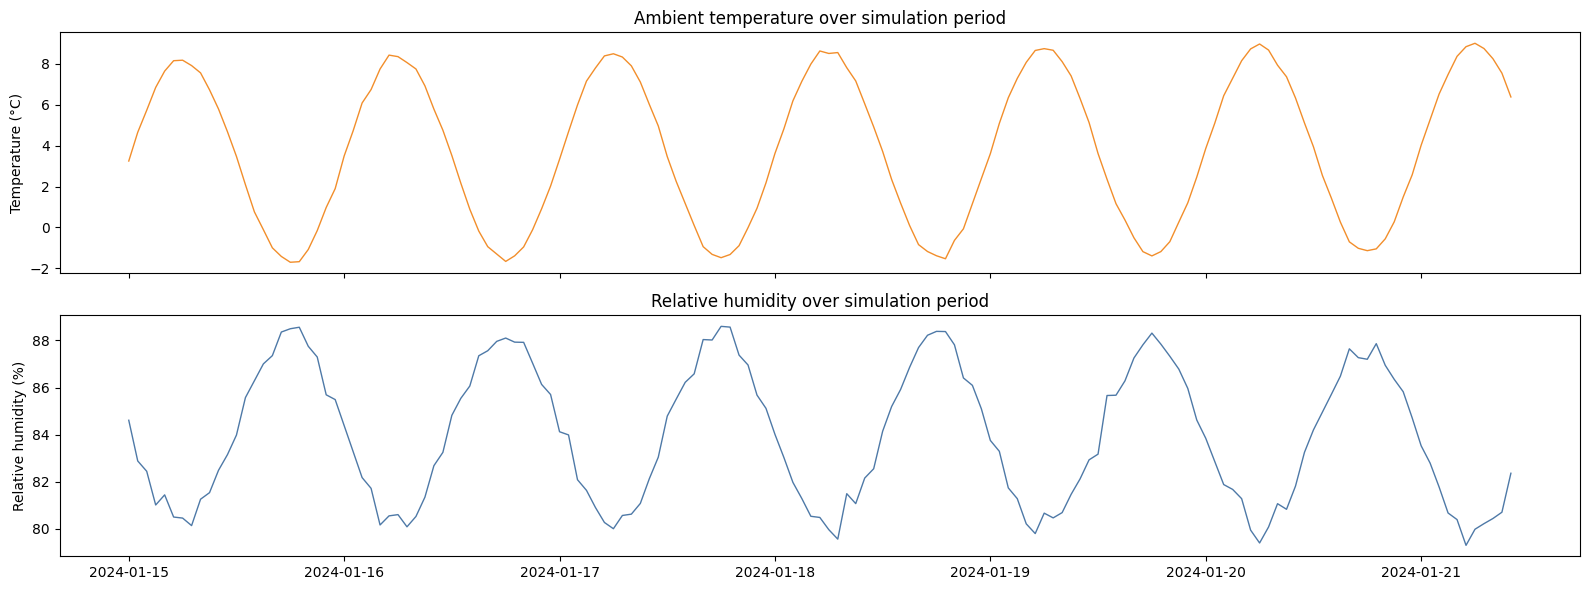

In [12]:
weather = (
    df_expanded
    .set_index('datetime_energy')[['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy']]
    .resample('1h').mean()
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(weather.index, weather['ef_temperature_2m_energy'], color='#f28e2b', lw=1)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Ambient temperature over simulation period')

ax2.plot(weather.index, weather['ef_relative_humidity_2m_energy'], color='#4e79a7', lw=1)
ax2.set_ylabel('Relative humidity (%)')
ax2.set_title('Relative humidity over simulation period')

plt.tight_layout()
plt.show()

## 8. Autoclave load – how many autoclave resources run in parallel

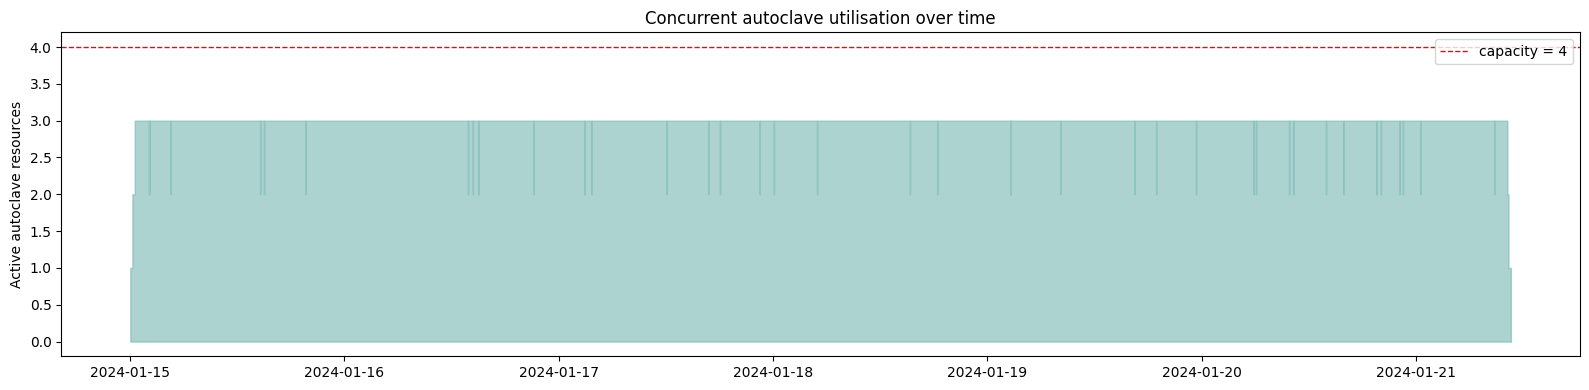

In [13]:
ac_events = df_event_log[df_event_log['station'] == 'Autoclaving'].copy()

# Build 1-minute timeline of concurrent autoclave usage
t_min = ac_events['timestamp_start'].min().floor('min')
t_max = ac_events['timestamp_end'].max().ceil('min')
timeline = pd.date_range(t_min, t_max, freq='min')

concurrent = np.zeros(len(timeline))
for _, row in ac_events.iterrows():
    mask = (timeline >= row['timestamp_start']) & (timeline < row['timestamp_end'])
    concurrent[mask] += 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(timeline, concurrent, step='pre', alpha=0.6, color='#76b7b2')
ax.set_ylabel('Active autoclave resources')
ax.set_title('Concurrent autoclave utilisation over time')
ax.axhline(4, color='red', linestyle='--', lw=1, label='capacity = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expanded dataset overview

In [14]:
df_expanded.head(5)

,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy,autoclave_steam_demand_kW_energy,autoclave_cooling_water_demand_kW_energy,bottling_power_kW_energy,packaging_power_kW_energy,water_supply_power_kW_energy,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,station_log,object_type_log,object_log,case_id_log,object_attributes_log
0,2024-01-15 00:00:00.000000,1.941789,75.487378,0.0,0.0,0.0,0.000000,0.0,0.882894,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
1,2024-01-15 00:00:06.559925,2.129406,91.428965,0.0,0.0,0.0,0.000000,0.0,8.102866,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,water_supply_working,sterilization_process,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
2,2024-01-15 00:01:14.906558,2.769762,80.791063,0.0,0.0,0.0,0.000000,0.0,0.000000,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,destillation_heat,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
3,2024-01-15 00:01:48.615250,2.765596,83.017738,0.0,0.0,0.0,5.292771,0.0,0.000000,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,bottling_prepare,sterilization_process,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
4,2024-01-15 00:01:55.175175,3.854121,73.527360,0.0,0.0,0.0,31.864168,0.0,0.000000,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,bottling_working,sterilization_process,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"


In [15]:
# Summary stats for energy sensors
sensors = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]
# Only non-zero rows per sensor
summary = {}
for s in sensors:
    d = df_expanded[df_expanded[s] > 0][s]
    summary[s] = {'n_rows': len(d), 'mean': d.mean(), 'std': d.std(),
                  'min': d.min(), 'max': d.max()}
pd.DataFrame(summary).T.round(2)

,n_rows,mean,std,min,max
destillation_steam_demand_kW_energy,249.0,2.36,1.98,0.00,10.33
autoclave_steam_demand_kW_energy,15012.0,169.96,68.86,0.00,227.67
autoclave_cooling_water_demand_kW_energy,12311.0,56.32,18.92,0.00,100.04
bottling_power_kW_energy,1500.0,14.97,14.19,3.43,43.29
packaging_power_kW_energy,4116.0,14.01,11.06,1.85,30.88
water_supply_power_kW_energy,1140.0,4.93,3.51,0.43,9.62


# 10. Conformance Diagnosis — Petri net approaches (no energy models)

Train/test split → mine Petri net from train → simulate on test → compute the exact same
conformance metrics as `modelling.py` to diagnose why precision = 0 for process_1.

## Metric guide

### Part A — Process model quality (Petri net vs real log)
These measure how well the mined Petri net captures the real process.
They do **not** involve the simulation output.

| Metric | What it measures | How to read it |
|--------|-----------------|----------------|
| **Fitness** | Can every event trace in the log be replayed by the Petri net without token errors? | 1.0 = all traces follow the model exactly. <0.8 = model is missing real behaviour the net cannot explain. |
| **Precision** | Does the net over-allow behaviour that never appears in the log? | 1.0 = net permits only what was observed. 0.4 = at each replay step the net enables ~2.5x more transitions than actually fired — the model is too permissive. |
| **Generalization** | Is the net overfitted to training traces? | ~0.9 = good. Penalises transitions that are rarely exercised relative to their maximum possible use. Computed on training log; same value reported for test (it is a net property, not a data property). |
| **Simplicity** | Structural complexity of the Petri net. | 1 / (1 + 0.005 x (places + transitions + arcs)). A 4-step sequential net ~0.92; a spaghetti net with loops scores lower. |

*Evaluated per station: each station's net is replayed only against that station's own events.*

---

### Part B — Simulation output vs real log (direct comparison)
These measure how closely the simulation's **generated events** match **reality**.
They compare `sim_log` directly to `df_train` or `df_test` — no Petri net involved.

| Metric | What it measures | How to read it | Ideal |
|--------|-----------------|----------------|-------|
| **Event ratio** | `len(sim_log) / len(real_log)` — does the sim produce the right number of events? | 1.0 = exact. >1 = sim over-generates; <1 = sim under-generates. ~2.14 here because the sim fires all resource objects per batch, not just one. | 1.0 |
| **Mean duration error** | `|sim_mean_duration - real_mean_duration| / real_mean_duration` | 0.0 = sim durations match reality on average. 0.2 = off by 20%. | 0.0 |
| **Median duration error** | Same but using medians — more robust to outlier activities. | 0.0 = perfect match. | 0.0 |
| **Activity dist (JS div)** | Jensen-Shannon divergence between the activity frequency distributions of sim and real. | 0.0 = identical distributions. 1.0 = completely different. Tells you if the sim generates the same mix of activities as reality. | 0.0 |
| **DFG edge precision** | Of all (A->B) directly-follows pairs in the sim log, what fraction also appear in the real log? | 1.0 = every sequence the sim generates was also seen in reality. Low = sim invents sequences that never happen. | 1.0 |
| **DFG edge recall** | Of all (A->B) pairs in the real log, what fraction also appear in the sim log? | 1.0 = sim reproduces all real sequences. Low = sim misses sequences that do happen in reality. | 1.0 |
| **DFG edge F1** | Harmonic mean of edge precision and recall. Single summary of control-flow similarity. | 1.0 = sim and reality have identical process flow. | 1.0 |

---

### Known artefacts

**Event ratio ~2.14 (structural):** `ProcessSimulation` runs each batch through every resource object (all 4 autoclaves + 7 others = ~30 events/batch). In reality each batch uses one autoclave only (~14 events/batch). This inflates event count, JS div, and DFG edge metrics.

**Precision = 1.0 (correct):** Evaluating each station's net against its own station-filtered log gives 1.0. The old 0.4 artefact came from evaluating the autoclaving net against the full 14-activity cross-station log.


In [16]:
import sys
sys.path.insert(0, str(Path('.').resolve()))

from sim_extractor import extract_process
from simulation import ProcessSimulation
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from scipy.spatial.distance import jensenshannon

try:
    from pm4py.algo.evaluation.generalization import algorithm as _pm4py_gen
except Exception:
    _pm4py_gen = None

try:
    from pm4py.algo.evaluation.simplicity import algorithm as _pm4py_sim
except Exception:
    _pm4py_sim = None

def _fitness(log_pm4py, net, im, fm):
    try:
        replay = token_replay.apply(log_pm4py, net, im, fm,
                                    parameters={'consider_remaining_in_fitness': True})
        scores = [float(r['trace_fitness']) for r in replay
                  if 'trace_fitness' in r and r['trace_fitness'] is not None]
        return float(np.mean(scores)) if scores else np.nan
    except Exception:
        return np.nan

def _precision(log_pm4py, net, im, fm):
    try:
        return float(pm4py.precision_token_based_replay(log_pm4py, net, im, fm))
    except Exception:
        return np.nan

def _generalization(log_pm4py, net, im, fm):
    if _pm4py_gen is None:
        return np.nan
    try:
        return float(_pm4py_gen.apply(log_pm4py, net, im, fm))
    except Exception:
        return np.nan

def _simplicity(net):
    if _pm4py_sim is not None:
        try:
            return float(_pm4py_sim.apply(net))
        except Exception:
            pass
    complexity = len(net.places) + len(net.transitions) + len(net.arcs)
    return float(1.0 / (1.0 + 0.005 * float(complexity)))

def to_pm4py_log(df):
    el = df.rename(columns={
        'case_id': 'case:concept:name',
        'activity': 'concept:name',
        'timestamp_start': 'time:timestamp',
    })[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    el['time:timestamp'] = pd.to_datetime(el['time:timestamp'])
    return pm4py.convert_to_event_log(el)

def _format_df(df):
    return pm4py.format_dataframe(
        df.dropna(subset=['case_id', 'activity', 'timestamp_start']),
        case_id='case_id', activity_key='activity', timestamp_key='timestamp_start')

def _compute_event_ratio(sim_df, real_df):
    return float(len(sim_df) / len(real_df)) if len(real_df) > 0 else np.nan

def _compute_duration_errors(sim_df, real_df):
    s = (sim_df['timestamp_end'] - sim_df['timestamp_start']).dt.total_seconds().dropna()
    r = (real_df['timestamp_end'] - real_df['timestamp_start']).dt.total_seconds().dropna()
    if len(s) == 0 or len(r) == 0:
        return np.nan, np.nan
    mean_err   = abs(s.mean()   - r.mean())   / r.mean()   if r.mean()   != 0 else np.nan
    median_err = abs(s.median() - r.median()) / r.median() if r.median() != 0 else np.nan
    return float(mean_err), float(median_err)

def _compute_js_divergence(sim_df, real_df):
    """Jensen-Shannon divergence between activity frequency distributions."""
    try:
        s_freq = sim_df['activity'].value_counts(normalize=True)
        r_freq = real_df['activity'].value_counts(normalize=True)
        acts   = sorted(set(s_freq.index) | set(r_freq.index))
        s_vec  = np.array([s_freq.get(a, 0.0) for a in acts])
        r_vec  = np.array([r_freq.get(a, 0.0) for a in acts])
        return float(jensenshannon(s_vec, r_vec))
    except Exception:
        return np.nan

def _compute_edge_metrics(sim_df, real_df):
    """DFG edge precision, recall, F1: sim output vs real log."""
    try:
        sim_fmt  = _format_df(sim_df)
        real_fmt = _format_df(real_df)
        sim_dfg,  _, _ = pm4py.discover_dfg(sim_fmt)
        real_dfg, _, _ = pm4py.discover_dfg(real_fmt)
        sim_edges  = set(sim_dfg.keys())
        real_edges = set(real_dfg.keys())
        if not sim_edges or not real_edges:
            return np.nan, np.nan, np.nan
        prec = len(sim_edges & real_edges) / len(sim_edges)
        rec  = len(sim_edges & real_edges) / len(real_edges)
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        return float(prec), float(rec), float(f1)
    except Exception:
        return np.nan, np.nan, np.nan

# 50/50 temporal split
_all_cases = (df_event_log.sort_values('timestamp_start')
                           .groupby('case_id')['timestamp_start'].min()
                           .sort_values().index.tolist())
_n_train    = max(1, len(_all_cases) // 2)
_train_cases = set(_all_cases[:_n_train])
_test_cases  = set(_all_cases[_n_train:])

df_train = df_event_log[df_event_log['case_id'].isin(_train_cases)].copy()
df_test  = df_event_log[df_event_log['case_id'].isin(_test_cases)].copy()

print(f'Train: {len(_train_cases)} cases / {len(df_train)} events')
print(f'Test:  {len(_test_cases)} cases  / {len(df_test)} events')


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.

Train: 250 cases / 3500 events
Test:  250 cases  / 3500 events



  ALGORITHM: INDUCTIVE

Processing: autoclaving_1 (sterilization_line) - sterilization_process
  Mining algorithm: inductive
  Found 4 unique activities: ['autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_1_hold'
 'autoclaving_1_cool']
    autoclaving_1_prepare: best fit = lognorm (0.020170883922098353, 0.0, 1.9977325825529864)
    autoclaving_1_heat: best fit = weibull_min (7.86706620507476, 0.0, 17.51429231355675)
    autoclaving_1_hold: best fit = weibull_min (6.7202961103781025, 0.0, 13.532401194222457)
    autoclaving_1_cool: best fit = weibull_min (7.453538724665084, 0.0, 27.10736378063901)
    Mining Petri net with 'inductive' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9727, fitness=1.0000, precision=1.0000, generalization=0.8908910548820038, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9727)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_1_prepare: Start=True, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_1_hold: Start=False, End=False, Transitions={'autoclaving_1_cool': 1.0}
      autoclaving_1_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_2 (sterilization_line) - sterilization_process
  Mining algorithm: inductive
  Found 4 unique activities: ['autoclaving_2_prepare' 'autoclaving_2_heat' 'autoclaving_2_hold'
 'autoclaving_2_cool']
    au

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9726, fitness=1.0000, precision=1.0000, generalization=0.8902357400103097, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9726)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_2_prepare: Start=True, End=False, Transitions={'autoclaving_2_heat': 1.0}
      autoclaving_2_heat: Start=False, End=False, Transitions={'autoclaving_2_hold': 1.0}
      autoclaving_2_hold: Start=False, End=False, Transitions={'autoclaving_2_cool': 1.0}
      autoclaving_2_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_3 (sterilization_line) - sterilization_process
  Mining algorithm: inductive
  Found 4 unique activities: ['autoclaving_3_prepare' 'autoclaving_3_heat' 'autoclaving_3_hold'
 'autoclaving_3_cool']
    au

...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=0.336  precision=0.159  generalization=0.891  simplicity=1.000
    TEST   fitness=0.340  precision=0.160  generalization=0.891  simplicity=1.000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 8
Building config from 22 activities:
  Config: ('autoclaving_1_prepare', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_heat': 1.0}
    Start: True
  Config: ('autoclaving_1_heat', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_hold': 1.0}
    Start: False
  Config: ('autoclaving_1_hold', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_cool': 1.0}
    Start: False
  Config: ('autoclaving_1_cool', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('autoclaving_2_prepare', 'autoclaving_2', 'st

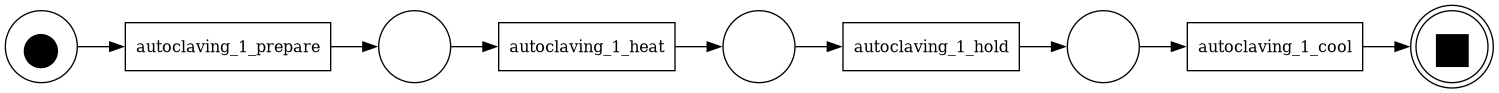


  ALGORITHM: HEURISTIC

Processing: autoclaving_1 (sterilization_line) - sterilization_process
  Mining algorithm: heuristic
  Found 4 unique activities: ['autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_1_hold'
 'autoclaving_1_cool']
    autoclaving_1_prepare: best fit = lognorm (0.020170883922098353, 0.0, 1.9977325825529864)
    autoclaving_1_heat: best fit = weibull_min (7.86706620507476, 0.0, 17.51429231355675)
    autoclaving_1_hold: best fit = weibull_min (6.7202961103781025, 0.0, 13.532401194222457)
    autoclaving_1_cool: best fit = weibull_min (7.453538724665084, 0.0, 27.10736378063901)
    Mining Petri net with 'heuristic' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9727, fitness=1.0000, precision=1.0000, generalization=0.8908910548820038, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9727)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_1_prepare: Start=True, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_1_hold: Start=False, End=False, Transitions={'autoclaving_1_cool': 1.0}
      autoclaving_1_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_2 (sterilization_line) - sterilization_process
  Mining algorithm: heuristic
  Found 4 unique activities: ['autoclaving_2_prepare' 'autoclaving_2_heat' 'autoclaving_2_hold'
 'autoclaving_2_cool']
    au

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9726, fitness=1.0000, precision=1.0000, generalization=0.8902357400103097, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9726)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_2_prepare: Start=True, End=False, Transitions={'autoclaving_2_heat': 1.0}
      autoclaving_2_heat: Start=False, End=False, Transitions={'autoclaving_2_hold': 1.0}
      autoclaving_2_hold: Start=False, End=False, Transitions={'autoclaving_2_cool': 1.0}
      autoclaving_2_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_3 (sterilization_line) - sterilization_process
  Mining algorithm: heuristic
  Found 4 unique activities: ['autoclaving_3_prepare' 'autoclaving_3_heat' 'autoclaving_3_hold'
 'autoclaving_3_cool']
    au

...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=0.336  precision=0.159  generalization=0.891  simplicity=1.000
    TEST   fitness=0.340  precision=0.160  generalization=0.891  simplicity=1.000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 8
Building config from 22 activities:
  Config: ('autoclaving_1_prepare', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_heat': 1.0}
    Start: True
  Config: ('autoclaving_1_heat', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_hold': 1.0}
    Start: False
  Config: ('autoclaving_1_hold', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_cool': 1.0}
    Start: False
  Config: ('autoclaving_1_cool', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('autoclaving_2_prepare', 'autoclaving_2', 'st

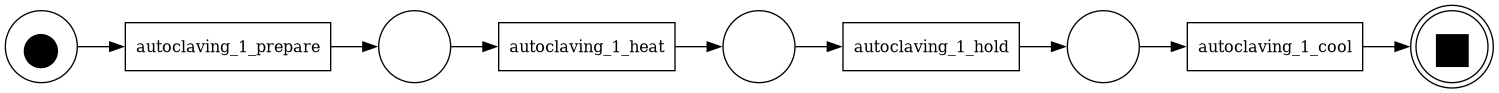


  ALGORITHM: ALPHA

Processing: autoclaving_1 (sterilization_line) - sterilization_process
  Mining algorithm: alpha
  Found 4 unique activities: ['autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_1_hold'
 'autoclaving_1_cool']
    autoclaving_1_prepare: best fit = lognorm (0.020170883922098353, 0.0, 1.9977325825529864)
    autoclaving_1_heat: best fit = weibull_min (7.86706620507476, 0.0, 17.51429231355675)
    autoclaving_1_hold: best fit = weibull_min (6.7202961103781025, 0.0, 13.532401194222457)
    autoclaving_1_cool: best fit = weibull_min (7.453538724665084, 0.0, 27.10736378063901)
    Mining Petri net with 'alpha' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9727, fitness=1.0000, precision=1.0000, generalization=0.8908910548820038, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9727)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_1_prepare: Start=True, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_1_hold: Start=False, End=False, Transitions={'autoclaving_1_cool': 1.0}
      autoclaving_1_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_2 (sterilization_line) - sterilization_process
  Mining algorithm: alpha
  Found 4 unique activities: ['autoclaving_2_prepare' 'autoclaving_2_heat' 'autoclaving_2_hold'
 'autoclaving_2_cool']
    autocl

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9726, fitness=1.0000, precision=1.0000, generalization=0.8902357400103097, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9726)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      autoclaving_2_prepare: Start=True, End=False, Transitions={'autoclaving_2_heat': 1.0}
      autoclaving_2_heat: Start=False, End=False, Transitions={'autoclaving_2_hold': 1.0}
      autoclaving_2_hold: Start=False, End=False, Transitions={'autoclaving_2_cool': 1.0}
      autoclaving_2_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: autoclaving_3 (sterilization_line) - sterilization_process
  Mining algorithm: alpha
  Found 4 unique activities: ['autoclaving_3_prepare' 'autoclaving_3_heat' 'autoclaving_3_hold'
 'autoclaving_3_cool']
    autocl

...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=0.336  precision=0.159  generalization=0.891  simplicity=1.000
    TEST   fitness=0.340  precision=0.160  generalization=0.891  simplicity=1.000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 8
Building config from 22 activities:
  Config: ('autoclaving_1_prepare', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_heat': 1.0}
    Start: True
  Config: ('autoclaving_1_heat', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_hold': 1.0}
    Start: False
  Config: ('autoclaving_1_hold', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'autoclaving_1_cool': 1.0}
    Start: False
  Config: ('autoclaving_1_cool', 'autoclaving_1', 'sterilization_line', 'sterilization_process')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('autoclaving_2_prepare', 'autoclaving_2', 'st

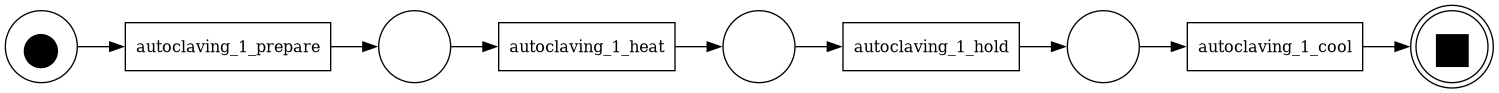

In [17]:
from IPython.display import Image, display as ipy_display
from pm4py.visualization.petri_net import visualizer as pn_vis

ALGORITHMS = ['inductive', 'heuristic', 'alpha']
results = []

def _run_simulation(stats_df, pp, process_models):
    sim = ProcessSimulation(activity_stats_df=stats_df, production_plan=pp,
                            mode='petri_net', process_models=process_models)
    return sim.run()

for algo in ALGORITHMS:
    print(f'\n{chr(61)*60}')
    print(f'  ALGORITHM: {algo.upper()}')
    print(f'{chr(61)*60}')

    stats_df, raw_df, process_models = extract_process(df_train, mining_algorithm=algo)

    # ── Part A: conformance (Petri net vs real log) ───────────────────────────
    fit_tr_list, prec_tr_list, gen_list, sim_list = [], [], [], []
    fit_te_list, prec_te_list = [], []
    seen_stations = set()
    for key, pm_entry in (process_models or {}).items():
        obj, obj_type, station = key
        if (obj_type, station) in seen_stations:
            continue
        seen_stations.add((obj_type, station))
        net_s, im_s, fm_s = pm_entry['net'], pm_entry['im'], pm_entry['fm']
        # With whole-process architecture, station = 'sterilization_process' -> full log
        if station == 'sterilization_process':
            df_tr_st = df_train.copy()
            df_te_st = df_test.copy()
        else:
            df_tr_st = df_train[df_train['station'] == station].copy()
            df_te_st = df_test[df_test['station'] == station].copy()
        log_tr_st = to_pm4py_log(df_tr_st)
        log_te_st = to_pm4py_log(df_te_st)
        fit_tr_list.append(_fitness(log_tr_st, net_s, im_s, fm_s))
        prec_tr_list.append(_precision(log_tr_st, net_s, im_s, fm_s))
        fit_te_list.append(_fitness(log_te_st, net_s, im_s, fm_s))
        prec_te_list.append(_precision(log_te_st, net_s, im_s, fm_s))
        gen_list.append(_generalization(log_tr_st, net_s, im_s, fm_s))
        sim_list.append(_simplicity(net_s))

    fit_tr  = float(np.nanmean(fit_tr_list))
    prec_tr = float(np.nanmean(prec_tr_list))
    fit_te  = float(np.nanmean(fit_te_list))
    prec_te = float(np.nanmean(prec_te_list))
    gen_val = float(np.nanmean(gen_list))
    sim_val = float(np.nanmean(sim_list))

    print(f'\n  [A] Conformance ({len(seen_stations)} net(s)):')
    print(f'    TRAIN  fitness={fit_tr:.3f}  precision={prec_tr:.3f}  generalization={gen_val:.3f}  simplicity={sim_val:.3f}')
    print(f'    TEST   fitness={fit_te:.3f}  precision={prec_te:.3f}  generalization={gen_val:.3f}  simplicity={sim_val:.3f}')

    # ── Part B: simulation output vs real log ─────────────────────────────────
    pp_train = df_production_plan[df_production_plan['case_id'].isin(_train_cases)].copy()
    if pp_train.empty:
        pp_train = df_production_plan.copy()
    pp_test = df_production_plan[df_production_plan['case_id'].isin(_test_cases)].copy()
    if pp_test.empty:
        pp_test = df_production_plan.copy()

    try:
        sim_log_tr = _run_simulation(stats_df, pp_train, process_models)
        evt_ratio_tr            = _compute_event_ratio(sim_log_tr, df_train)
        mean_dur_tr, med_dur_tr = _compute_duration_errors(sim_log_tr, df_train)
        js_tr                   = _compute_js_divergence(sim_log_tr, df_train)
        edge_prec_tr, edge_rec_tr, edge_f1_tr = _compute_edge_metrics(sim_log_tr, df_train)
        print(f'\n  [B] Sim vs TRAIN:')
        print(f'    evt_ratio={evt_ratio_tr:.3f}  mean_dur_err={mean_dur_tr:.3f}  med_dur_err={med_dur_tr:.3f}')
        print(f'    js_div={js_tr:.3f}  edge_prec={edge_prec_tr:.3f}  edge_rec={edge_rec_tr:.3f}  edge_f1={edge_f1_tr:.3f}')
    except Exception as e:
        print(f'  [TRAIN SIM] failed: {e}')
        evt_ratio_tr = mean_dur_tr = med_dur_tr = np.nan
        js_tr = edge_prec_tr = edge_rec_tr = edge_f1_tr = np.nan

    try:
        sim_log_te = _run_simulation(stats_df, pp_test, process_models)
        evt_ratio_te            = _compute_event_ratio(sim_log_te, df_test)
        mean_dur_te, med_dur_te = _compute_duration_errors(sim_log_te, df_test)
        js_te                   = _compute_js_divergence(sim_log_te, df_test)
        edge_prec_te, edge_rec_te, edge_f1_te = _compute_edge_metrics(sim_log_te, df_test)
        print(f'\n  [B] Sim vs TEST:')
        print(f'    evt_ratio={evt_ratio_te:.3f}  mean_dur_err={mean_dur_te:.3f}  med_dur_err={med_dur_te:.3f}')
        print(f'    js_div={js_te:.3f}  edge_prec={edge_prec_te:.3f}  edge_rec={edge_rec_te:.3f}  edge_f1={edge_f1_te:.3f}')
    except Exception as e:
        print(f'  [TEST SIM] failed: {e}')
        evt_ratio_te = mean_dur_te = med_dur_te = np.nan
        js_te = edge_prec_te = edge_rec_te = edge_f1_te = np.nan

    results.append({
        'algo': algo,
        # Part A
        'train_fitness': fit_tr,   'train_precision': prec_tr,
        'train_generalization': gen_val, 'train_simplicity': sim_val,
        # Part B train
        'train_evtratio': evt_ratio_tr,
        'train_meandurerr': mean_dur_tr, 'train_meddurerr': med_dur_tr,
        'train_jsdiv': js_tr,
        'train_edgeprec': edge_prec_tr, 'train_edgerec': edge_rec_tr, 'train_edgef1': edge_f1_tr,
        # Part A test
        'test_fitness': fit_te,    'test_precision': prec_te,
        'test_generalization': gen_val,  'test_simplicity': sim_val,
        # Part B test
        'test_evtratio': evt_ratio_te,
        'test_meandurerr': mean_dur_te,  'test_meddurerr': med_dur_te,
        'test_jsdiv': js_te,
        'test_edgeprec': edge_prec_te, 'test_edgerec': edge_rec_te, 'test_edgef1': edge_f1_te,
    })

    # visualise first Petri net
    try:
        first_key = next(iter(process_models or {}))
        pm_vis    = process_models[first_key]
        log_train_pm4py = to_pm4py_log(df_train)
        gviz = pn_vis.apply(pm_vis['net'], pm_vis['im'], pm_vis['fm'],
                            variant=pn_vis.Variants.FREQUENCY,
                            parameters={'log': log_train_pm4py})
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
            pn_vis.save(gviz, f.name)
            obj_v, _, sta_v = first_key
            print(f'\n    Petri net ({algo} / {obj_v} - {sta_v}):')
            ipy_display(Image(filename=f.name))
    except Exception as e:
        print(f'    (visualisation failed: {e})')

,algo,train_fitness,train_precision,train_generalization,train_simplicity,train_evtratio,train_meandurerr,train_meddurerr,train_jsdiv,train_edgeprec,...,test_precision,test_generalization,test_simplicity,test_evtratio,test_meandurerr,test_meddurerr,test_jsdiv,test_edgeprec,test_edgerec,test_edgef1
0,inductive,0.336,0.1587,0.8909,1.0,0.2857,1.6315,6.4695,0.7283,1.0,...,0.1598,0.8909,1.0,0.2857,1.718,7.9808,0.7274,1.0,0.1304,0.2308
1,heuristic,0.336,0.1587,0.8909,1.0,0.2857,1.6315,6.4695,0.7283,1.0,...,0.1598,0.8909,1.0,0.2857,1.718,7.9808,0.7274,1.0,0.1304,0.2308
2,alpha,0.336,0.1587,0.8909,1.0,0.2857,1.6315,6.4695,0.7283,1.0,...,0.1598,0.8909,1.0,0.2857,1.718,7.9808,0.7274,1.0,0.1304,0.2308


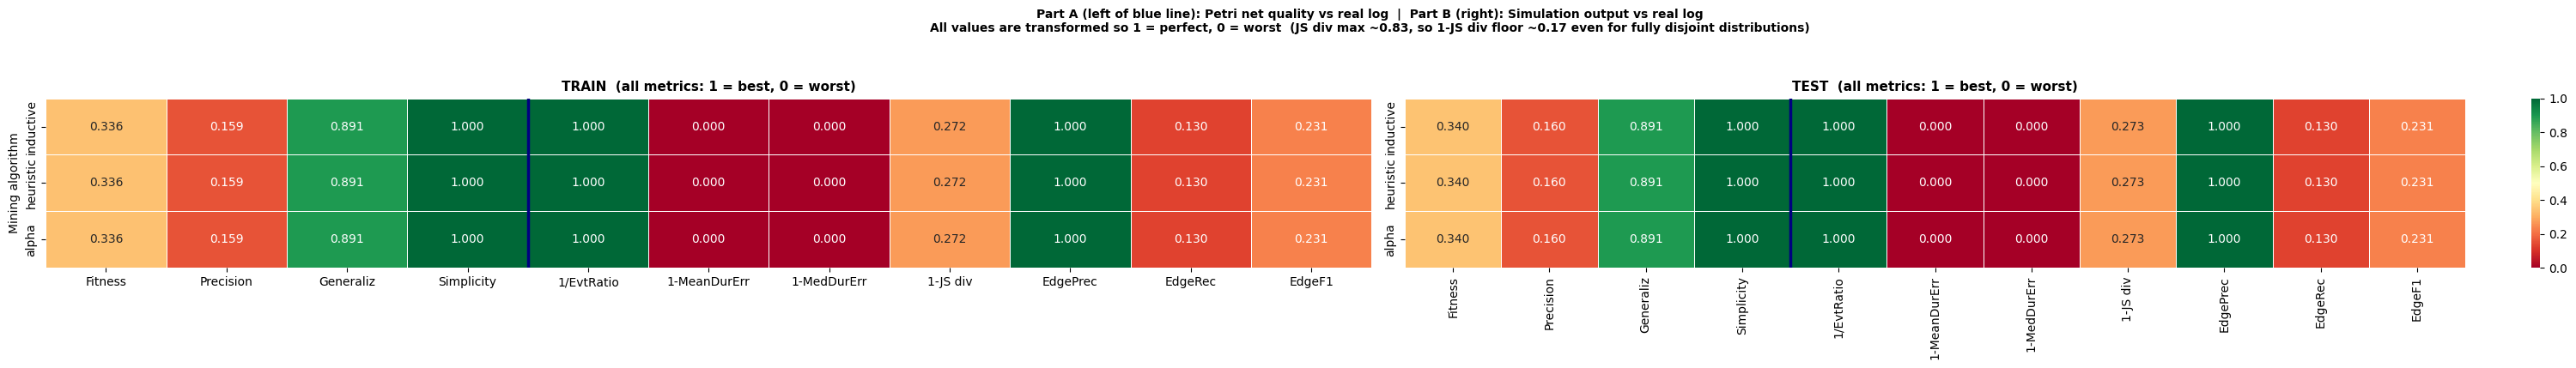


Note: Generalization is a net+training-log property -- same value in both splits.
Note: EvtRatio, JS div, and edge metrics are affected by the sim firing all resource objects (~2.14x events).


In [18]:
res_df = pd.DataFrame(results)
display(res_df.round(4))

if not res_df.empty:
    COLS_A = ['fitness', 'precision', 'generalization', 'simplicity']
    COLS_B = ['evtratio', 'meandurerr', 'meddurerr', 'jsdiv', 'edgeprec', 'edgerec', 'edgef1']
    ALL_COLS = COLS_A + COLS_B

    # All values transformed so that 1 = best, 0 = worst
    LABELS = [
        'Fitness', 'Precision', 'Generaliz', 'Simplicity',  # Part A: already 0-1, higher=better
        '1/EvtRatio',    # 1.0 when ratio=1.0; 0.47 when ratio=2.14
        '1-MeanDurErr',  # 1.0 when error=0; 0.0 when error=1
        '1-MedDurErr',   # same
        '1-JS div',      # 1.0 when distributions identical (JS div=0); 0.17 when fully disjoint (JS div~0.83)
        'EdgePrec', 'EdgeRec', 'EdgeF1',  # already 0-1, higher=better
    ]

    def _to_heatmap(res_df, split):
        hm = res_df.set_index('algo')[[f'{split}_{c}' for c in ALL_COLS]].copy().astype(float)
        # EvtRatio: 1/r so that 1.0 = perfect, <1 = over/under-generation
        col = f'{split}_evtratio'
        hm[col] = (1.0 / hm[col].replace(0, np.nan)).clip(0, 1)
        # Lower-is-better metrics: 1 - value
        for c in ('meandurerr', 'meddurerr', 'jsdiv'):
            col = f'{split}_{c}'
            hm[col] = (1.0 - hm[col]).clip(0, 1)
        hm.columns = LABELS
        return hm

    train_hm = _to_heatmap(res_df, 'train')
    test_hm  = _to_heatmap(res_df, 'test')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(32, max(3, len(res_df) + 1)))

    sns.heatmap(train_hm.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, cbar=False, ax=ax1)
    ax1.set_title('TRAIN  (all metrics: 1 = best, 0 = worst)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Mining algorithm')
    ax1.axvline(x=len(COLS_A), color='navy', linewidth=2.5)

    sns.heatmap(test_hm.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax2)
    ax2.set_title('TEST  (all metrics: 1 = best, 0 = worst)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('')
    ax2.axvline(x=len(COLS_A), color='navy', linewidth=2.5)

    plt.suptitle(
        'Part A (left of blue line): Petri net quality vs real log  |  '
        'Part B (right): Simulation output vs real log\n'
        'All values are transformed so 1 = perfect, 0 = worst  '
        '(JS div max ~0.83, so 1-JS div floor ~0.17 even for fully disjoint distributions)',
        fontsize=10, fontweight='bold', y=1.06)
    plt.tight_layout()
    plt.show()

    print('\nNote: Generalization is a net+training-log property -- same value in both splits.')
    print('Note: EvtRatio, JS div, and edge metrics are affected by the sim firing all resource objects (~2.14x events).')
